In [1]:
# Visualize an Open Ephys Neuropixels probe-survey JSON.
#
# A probe survey cycles through every bank on every shank and measures a
# per-electrode AP-band peak-to-peak amplitude — a signal-quality proxy used
# to decide which bank to select on each shank before recording. This
# notebook only visualizes the survey; the actual channel map is built with
# a separate tool.

In [1]:
#%%
# path and params
from pathlib import Path
sys_path_root = Path("..")

survey_json_path = sys_path_root / "assets" / "neuropixels_survey_2026-08-31_15-36-28.json"
save_dir = Path(r"C:\Users\Jeff\Downloads\output_optonpx")
METRIC = "peak_to_peak"

In [2]:
#%%
import sys
import json
import matplotlib.pyplot as plt
from IPython.core.getipython import get_ipython

sys.path.append(str(Path(__file__).parent.parent) if "__file__" in dir() else "..")
ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic("matplotlib", "inline")
    ipython.run_line_magic("config", "InlineBackend.figure_format = 'svg'")

from src import plot_probe_survey

with open(survey_json_path, "r", encoding="utf-8") as f:
    survey = json.load(f)

print(f"Survey file      : {survey_json_path.name}")
print(f"Generated at     : {survey['generated_at']}")
print(f"Seconds / config : {survey['seconds_per_configuration']}")
print(f"Probes           : {survey['probe_count']}")
for p in survey["probes"]:
    print(f"  {p['name']}  serial={p['serial_number']}  "
          f"shanks={p['shanks_surveyed']}  banks={p['banks_surveyed']}  "
          f"electrodes={len(p['electrodes'])}")

Survey file      : neuropixels_survey_2026-08-31_15-36-28.json
Generated at     : 2026-08-31T15:36:28.148-07:00
Seconds / config : 10.0
Probes           : 2
  ProbeA  serial=25048419171  shanks=[0, 1, 2, 3]  banks=['A', 'B', 'C', 'D']  electrodes=5120
  ProbeB  serial=25048411301  shanks=[0, 1, 2, 3]  banks=['A', 'B', 'C', 'D']  electrodes=5120


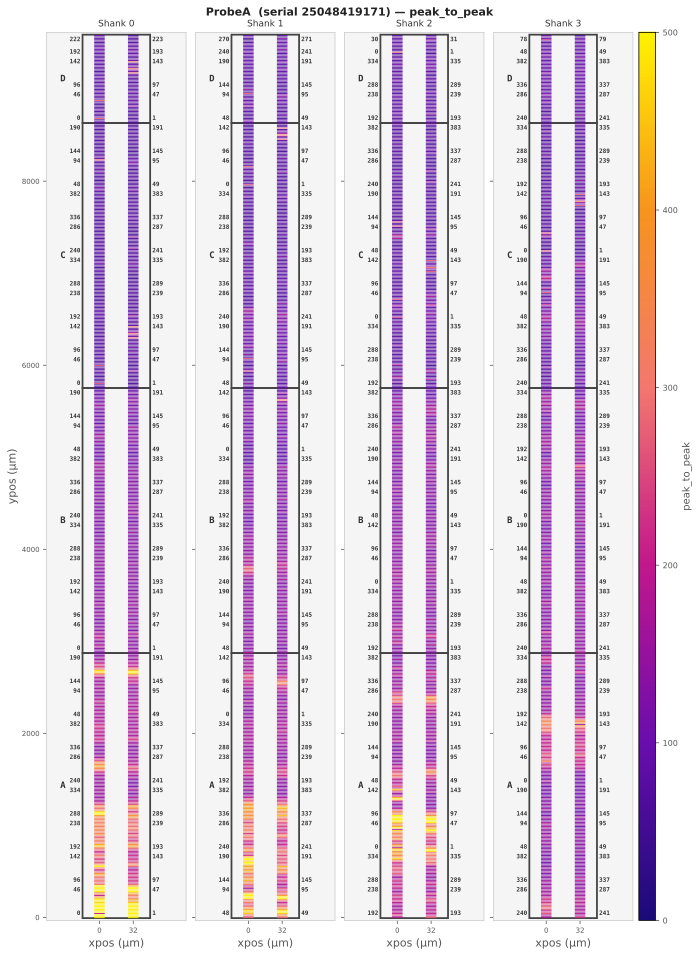

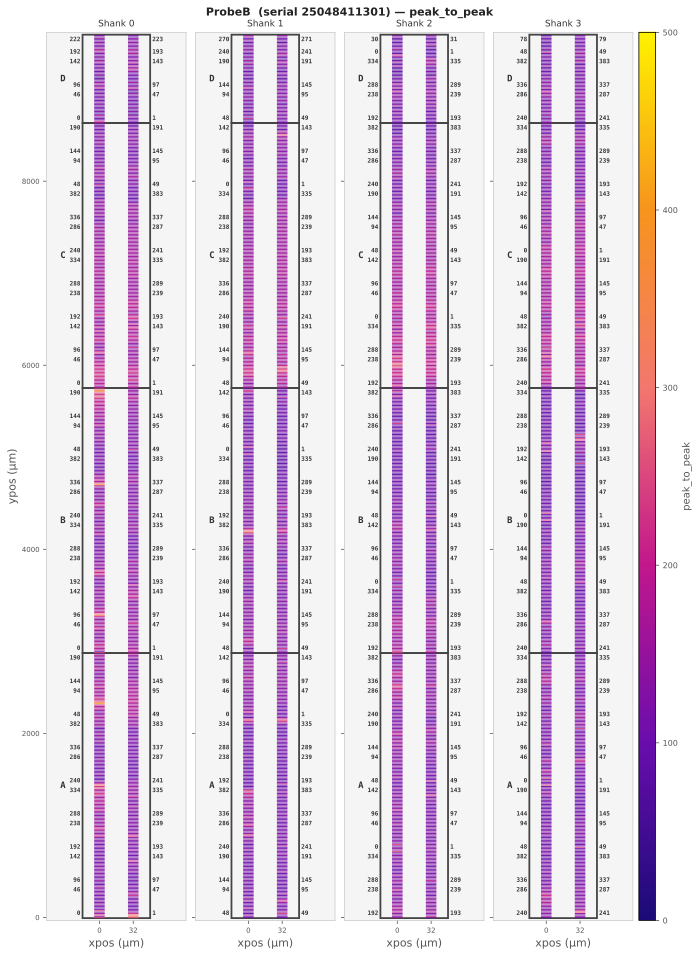

Figures saved to: C:\Users\Jeff\Downloads\output_optonpx


In [3]:
#%%
# spatial heatmap, one figure per probe
save_dir.mkdir(parents=True, exist_ok=True)

for probe in survey["probes"]:
    electrodes = probe["electrodes"]
    label = f"{probe['name']}  (serial {probe['serial_number']})"

    fig_map = plot_probe_survey(electrodes, metric=METRIC, title=f"{label} — {METRIC}")
    if ipython is not None:
        plt.show()
    fig_map.savefig(save_dir / f"{probe['name']}_survey_{METRIC}_map.png",
                    bbox_inches="tight", dpi=200)

print(f"Figures saved to: {save_dir}")

In [4]:
#%%
# interactive version: hover an electrode to see its shank/bank/row/column/
# global_index and value (a survey has no recorded "channel" yet — this is
# the identifying info to reference when building the real channel map)
from bokeh.plotting import show as bokeh_show
from src import plot_probe_survey_interactive

for probe in survey["probes"]:
    electrodes = probe["electrodes"]
    label = f"{probe['name']}  (serial {probe['serial_number']})"

    grid = plot_probe_survey_interactive(electrodes, metric=METRIC, title=f"{label} — {METRIC}")
    if ipython is not None:
        bokeh_show(grid)